In [17]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./mixture_of_gaussians/output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

In [14]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'rw' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)
        
max_before_tempering_is_one = max([int(jnp.min(jnp.argwhere(PKLs[idx]['res'][6]==1), axis=0)[1]) for idx in range(n)]) + 1

IndexError: list index out of range

/tmp/ipykernel_24119/1829894883.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


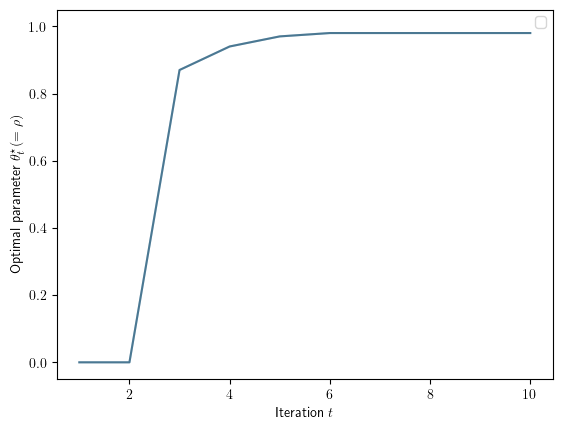

In [45]:
for idx in list_idx_ar:
    xaxis = range(1, max_before_tempering_is_one +1 )
    all_parameters = PKLs[idx]['res'][3][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][3].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][3][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel(r'Optimal parameter $\theta_t^{\star} (=\rho)$')
plt.xlabel(r"Iteration $t$")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.savefig(DIR+"AR_optimal_parameter.png")

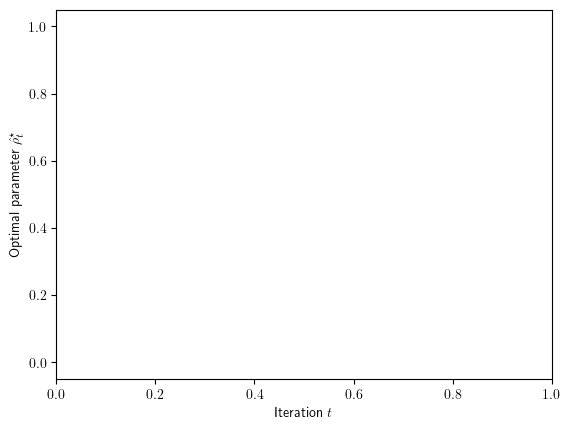

In [3]:
max_before_tempering_is_one=10
for idx in list_idx_ar:
    xaxis = range(max_before_tempering_is_one)
    all_parameters = PKLs[idx]['res'][3][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][3].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][3][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel(r'Optimal parameter $\hat{\rho}_t^{\star}$')
plt.xlabel(r"Iteration $t$")
plt.ylim(-0.05, 1.05)
plt.title("")
plt.savefig(DIR+"AR_optimal_parameter.pdf")

/tmp/ipykernel_237078/3178601512.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


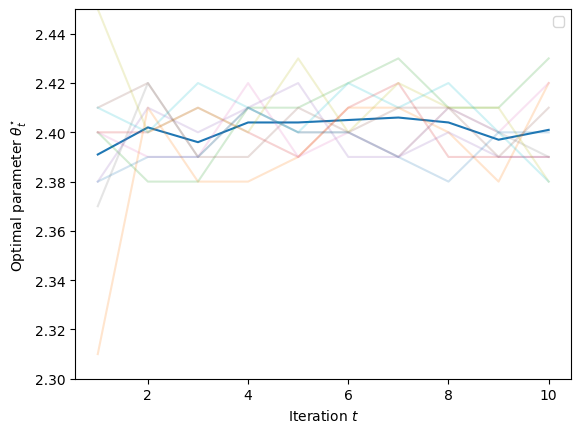

In [21]:
for idx in list_idx_rwmh:
    xaxis = range(1, max_before_tempering_is_one +1 )
    all_parameters = PKLs[idx]['res'][3][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][3].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][3][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel(r'Optimal parameter $\theta_t^{\star}$')
plt.xlabel(r"Iteration $t$")
plt.ylim(2.3, 2.45)
plt.legend()
plt.savefig(DIR+"RW_optimal_parameter.png")

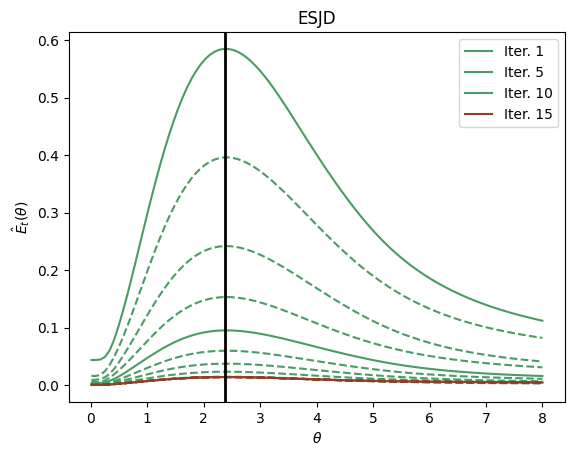

In [32]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
idx = 0
for j in range(PKLs[idx]['res'][5].shape[1]):
    criteria_function = PKLs[idx]['res'][5].mean(axis=0) 
    plt.plot(GRID_ESJD, criteria_function[j], label=f"Iter. {str(j+1)}" if j in [0, 4, 9, 14, 19] else None, color=color_set[j//10], linestyle="solid" if  j in [0, 4, 9, 14, 19] else "--")
plt.axvline(x=2.38, ymin=0, ymax = 1, linewidth=2, color='k')
plt.legend()
plt.title("ESJD")
plt.ylabel(r"$\hat{E}_t(\theta)$")
plt.xlabel(r'$\theta$')
plt.savefig(DIR+f"{PKL_titles[idx]}criteria_function.png")

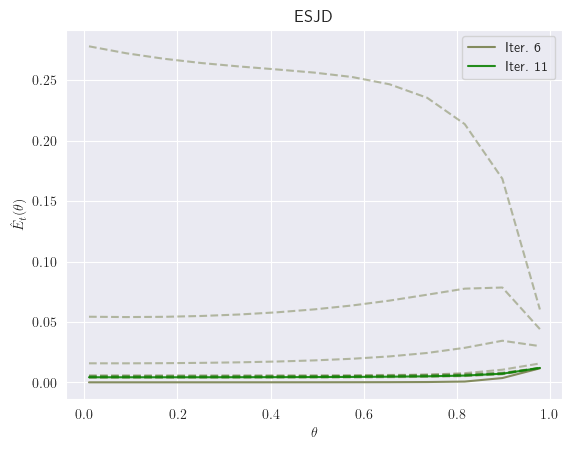

In [12]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
idx = 0
for j in range(1, PKLs[idx]['res'][5].shape[1]):
    criteria_function = PKLs[idx]['res'][5].mean(axis=0) 
    plt.plot(GRID_ESJD, criteria_function[j], label=f"Iter. {str(j+1)}" if j%5==0 else None, alpha=0.9 if j%5==0 else 0.5, color=color_set[j//10], linestyle="solid" if j%5==0 else "--")
plt.legend()
plt.title("ESJD")
plt.ylabel(r"$\hat{E}_t(\theta)$")
plt.xlabel(r'$\theta$')
plt.savefig(DIR+f"{PKL_titles[idx]}criteria_function.png")

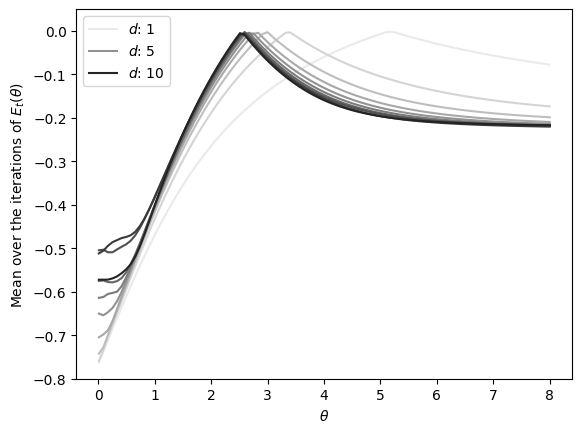

In [5]:
grays = [
    "#EAEAEA",  # Lightest gray
    "#D4D4D4",
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424"   # Darkest gray
]
GRID_ESJD = jnp.linspace(0.01, 8, 100)

dims = {}
for idx in range(n):
    dims[PKLs[idx]['config']['dim']] = idx 
for dim in range(1, 11):
    idx = dims[dim]
    criteria_function = PKLs[idx]['res'][5].mean(axis=[0, 1])
    plt.plot(GRID_ESJD, criteria_function, linestyle="solid", color=grays[PKLs[idx]['config']['dim']-1], label=rf"$d$: {str(PKLs[idx]['config']['dim'])}" if dim in [1, 5, 10] else None)
plt.ylabel(r"Mean over the iterations of $E_t(\theta)$")
plt.xlabel(r"$\theta$")
plt.ylim( -0.8, 0.05,)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.savefig(DIR+"target_AR_rwm_across_dim_estimate_mean_over_iteration.pdf")

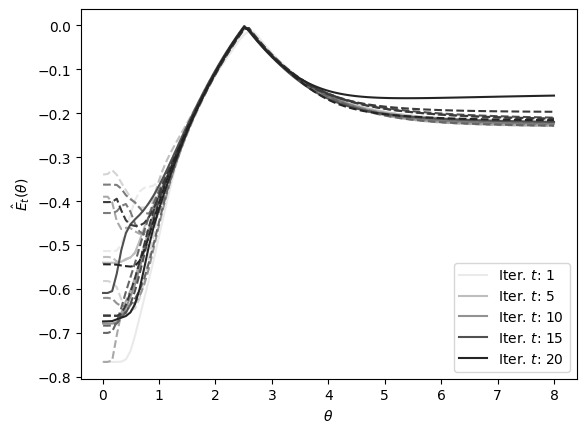

In [27]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
dim = 10
idx = dims[dim]
for j in range(0, PKLs[idx]['res'][5].shape[1]):
    criteria_function = PKLs[idx]['res'][5].mean(axis=0) 
    plt.plot(GRID_ESJD, criteria_function[j], label=rf"Iter. $t$: {str(j+1)}" if j in [0, 4, 9, 14,19] else None, color=grays[j//2], linestyle="solid" if j in [0, 4, 9, 14,19] else "--")
plt.legend()
plt.ylabel(r"$\hat{E}_t(\theta)$")
plt.xlabel(r'$\theta$')
plt.savefig(DIR+f"{PKL_titles[idx]}criteria_function_for_dim10.pdf")

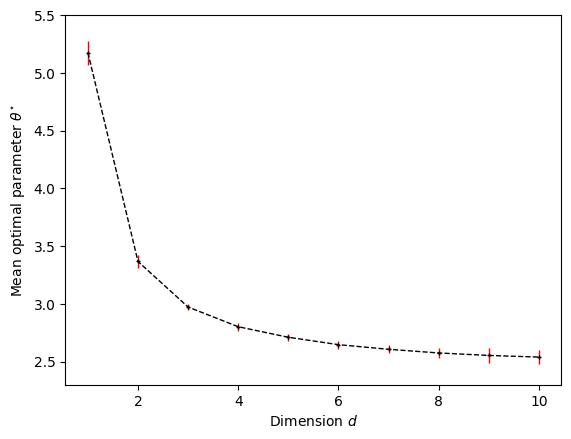

In [6]:
xaxis = range(1, 11)
all_parameters = np.array([PKLs[dims[dim]]['res'][3].mean() for dim in range(1, 11)])
std = np.array([PKLs[dims[dim]]['res'][3].std() for dim in range(1, 11)])
plt.errorbar(x=xaxis, y=all_parameters, yerr=2*std, color="black", linestyle="--", marker="+", markersize=3, ecolor="red", linewidth=1.0)
plt.ylabel(r'Mean optimal parameter $\theta^{\star}$')
plt.xlabel(r"Dimension $d$")
plt.ylim(2.3, 5.5)
plt.savefig(DIR+"RW_optimal_parameter_across_dim_target_ar.pdf")

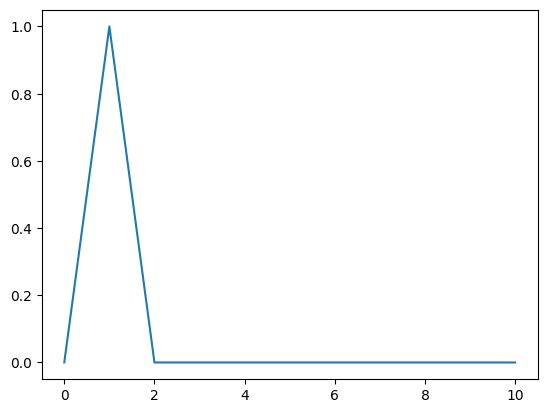

In [21]:
plt.plot(PKLs[0]['res'][3][0, :, 0])

In [18]:
PKLs[0]['res'][3].shape

(1, 11, 3)